In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.tree import plot_tree


In [2]:
df=pd.read_csv('Student_Performance.csv')
data = pd.read_csv('Student_Performance.csv')

In [3]:
# Display Top 5 Rows of the DataFrame
data.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
# Check shape of the Dataframe
data.shape

(10000, 6)

In [5]:
# Quick Summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
# Check For Duplicates
data.duplicated().any()

True

In [7]:
# Drop duplicates
data.drop_duplicates(keep='first', inplace=True)
data.shape

(9873, 6)

In [24]:
data['Extracurricular Activities']=data['Extracurricular Activities'].map({'Yes':1,'No':0})

In [23]:
# Quick Statistics
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [9]:
data['Hours Studied'].value_counts()

Hours Studied
1    1133
6    1122
7    1118
3    1110
9    1099
2    1077
8    1074
4    1071
5    1069
Name: count, dtype: int64

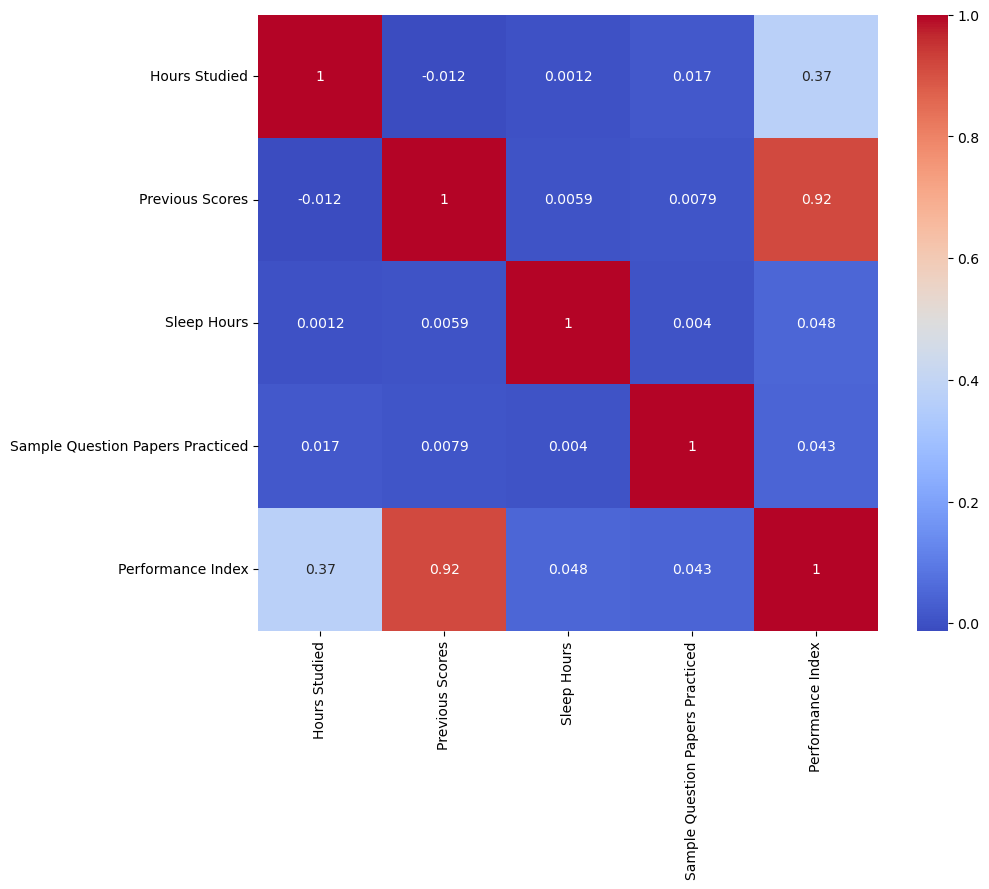

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,cmap='coolwarm')
plt.show()


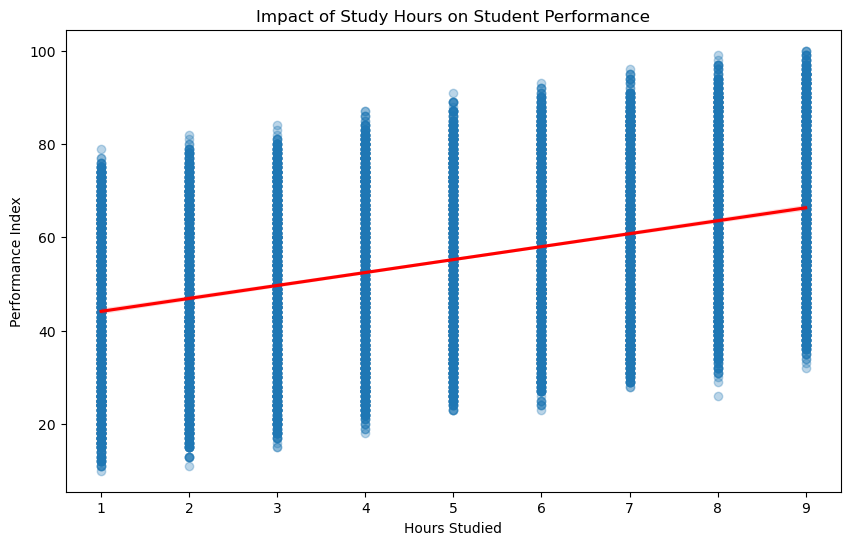

In [11]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='Hours Studied',
            y='Performance Index',line_kws={"color":"red"},
            scatter_kws={'alpha':0.3})
plt.title('Impact of Study Hours on Student Performance')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.show()

In [28]:
X=data.drop('Performance Index',axis=1)
y=data['Performance Index']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
predictions=rf_model.predict(X_test)
r2=r2_score(y_test,predictions)
rmse=np.sqrt(mean_squared_error(y_test,predictions))
print(f"R-squared:{r2}")
print(f"RMSE:{rmse}")

R-squared:0.9848749751312796
RMSE:2.372551548642623


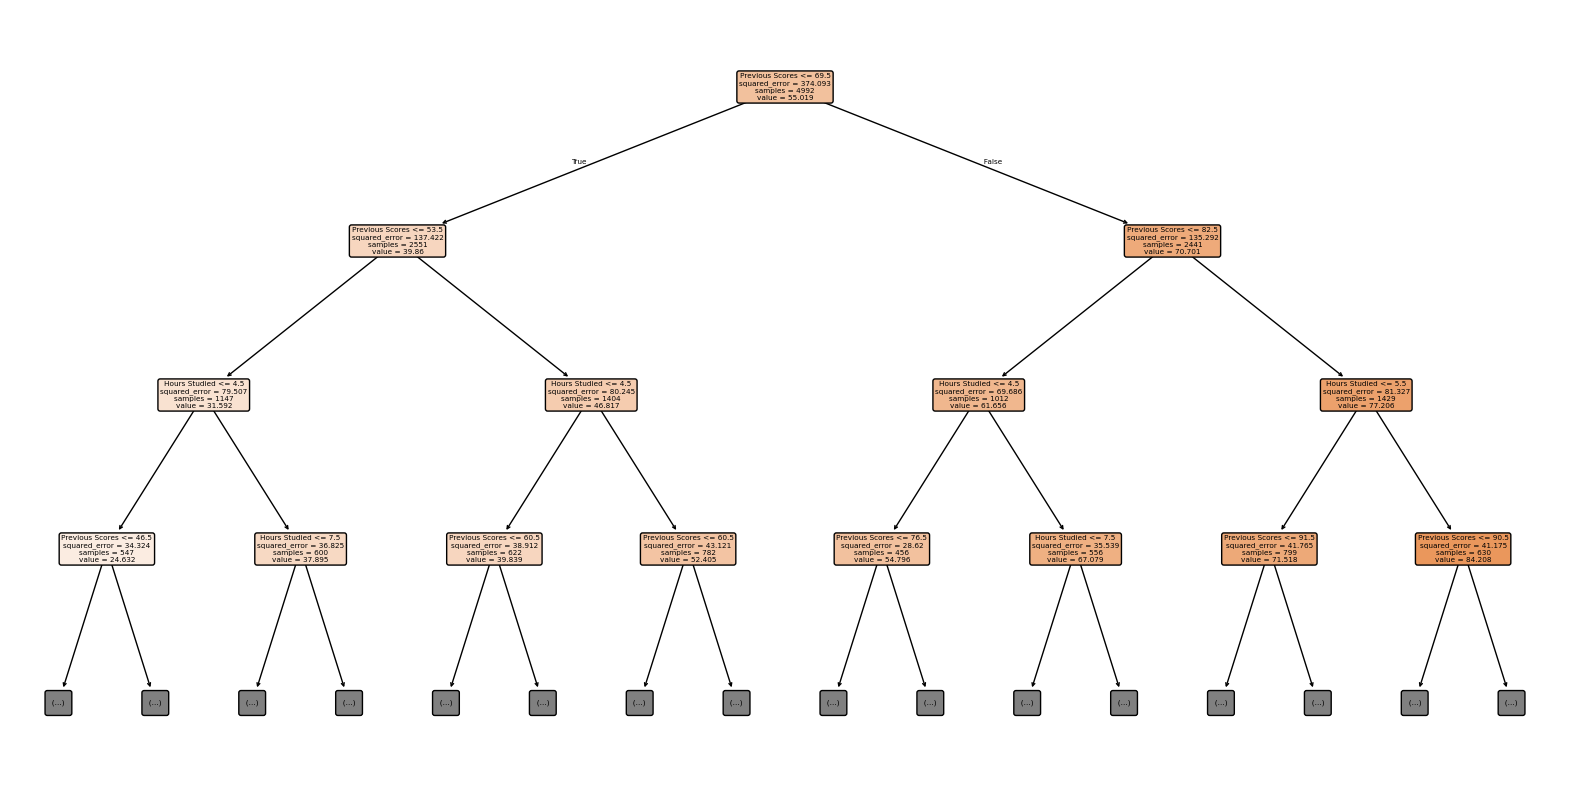

In [32]:
plt.figure(figsize=(20,10))
plot_tree(rf_model.estimators_[0],
          feature_names=X.columns,
          filled=True,
          rounded=True,
          max_depth=3)
plt.show()